#**Instalación de Dependencias**

In [34]:
#Instalación de librería wandb

!pip install wandb -q
!pip install tensorflow

#**Importación de Librerías Requeridas**

In [35]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import wandb

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from wandb.integration.keras import WandbMetricsLogger

epocas=10 #Epocas para el entrenamiento

#**Inicialización de Weights & Biases**

In [36]:
wandb.login()

wandb.init(
    project="clasificador-flores",
    name="cnn-basica"
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


epoch/accuracy,▁▃▄▅▅▆▆▇██
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▄▃▃▂▁▁
epoch/val_accuracy,▁▄▅▆▇▆▇██▇
epoch/val_loss,█▇▄▃▃▃▂▁▂▄
epoch/accuracy,0.87534
epoch/epoch,9
epoch/learning_rate,0.001
epoch/loss,0.34194
epoch/val_accuracy,0.69482


#**Cargar Dataset**

Se van a utilizar los dataset de TensorFlow

In [37]:
import tensorflow_datasets as tfds

dataset, info=tfds.load(
    "tf_flowers",
    as_supervised=True,
    with_info=True
)

#**Mostrar Clases**

In [38]:
print(info.features["label"].names)

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


#**Preprocesamiento**
Redimensionamiento de imágendes

In [39]:
IMG_SIZE=128

def preprocess(image, label):
  image=tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
  image=image/255.0
  return image, label

#**División del Dataset**

In [40]:
train_ds=dataset["train"].map(preprocess)

train_size=int(0.8 * info.splits["train"].num_examples)

train_dataset=train_ds.take(train_size)
test_dataset=train_ds.skip(train_size)

BATCH_SIZE=32

train_dataset=train_dataset.shuffle(1000).batch(BATCH_SIZE)
test_dataset=test_dataset.batch(BATCH_SIZE)

#**Visualizar Imágenes**

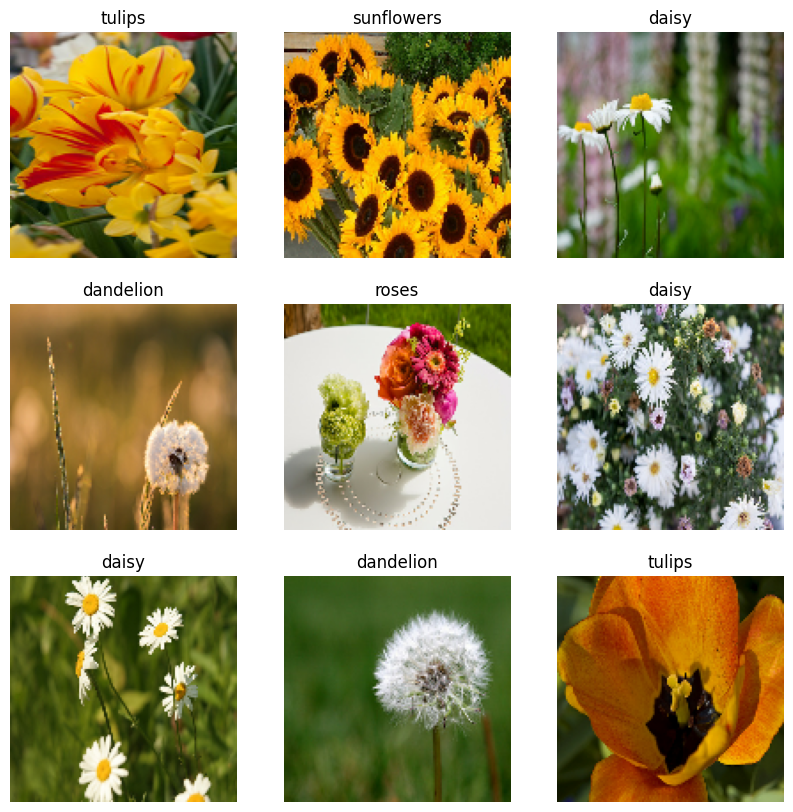

In [41]:
class_names=info.features["label"].names

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
  for i in range(9):
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

#**Construir de la Red Neuronal Convolusional (CNN)**

In [42]:
model=models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(128,128,3)),

    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#**Compilación**

In [43]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#**Entrenamiento del Modelo**

In [44]:
history=model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epocas,
    callbacks=[WandbMetricsLogger()]
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.4475 - loss: 1.3312 - val_accuracy: 0.5368 - val_loss: 1.0949
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.5623 - loss: 1.1262 - val_accuracy: 0.6090 - val_loss: 0.9493
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.6267 - loss: 0.9634 - val_accuracy: 0.6580 - val_loss: 0.8688
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.6788 - loss: 0.8489 - val_accuracy: 0.6471 - val_loss: 0.9143
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.7091 - loss: 0.7392 - val_accuracy: 0.7316 - val_loss: 0.7340
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7527 - loss: 0.6467 - val_accuracy: 0.7030 - val_loss: 0.7593
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7987 - loss: 0.5276 - val_accuracy: 0.7289 - val_loss: 0.7719
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.8409 - loss: 0.4345 - val_accuracy: 0.7207 - val_loss

#**Evaluación**

In [45]:
loss, accuracy=model.evaluate(test_dataset)

print("Accuracy: ", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.7221 - loss: 0.9040
Accuracy:  0.7220708727836609


#**Gráficas**

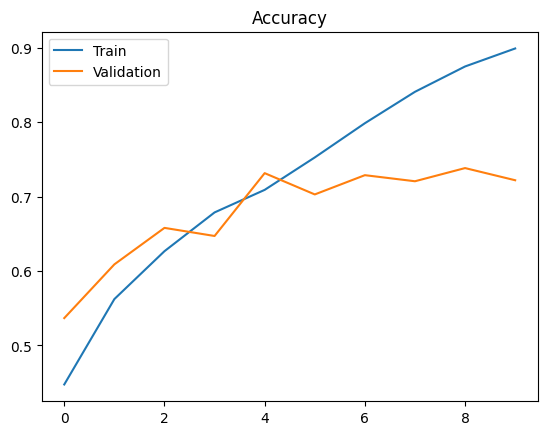

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()